# CSET343 — AI in Healthcare
## Lab Assignment 6: CNN-Based Chest X-Ray Classification

**Objective:** Design and evaluate CNN models for automated diagnosis using Chest X-Ray Images.

**Dataset:** Chest X-Ray Images — Normal and Pneumonia

This notebook covers:
1. Data acquisition and exploration
2. Image preprocessing
3. HOG, LBP and GLCM feature extraction
4. 70/15/15 train-validation-test split
5. CNN training
6. Hyperparameter tuning
7. Accuracy, Precision, Recall, F1-score and AUROC
8. Confusion matrix and misclassification analysis
9. Comparison of CNN and handcrafted-feature model


In [8]:
!pip -q install kagglehub scikit-image


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import os, random, numpy as np, pandas as pd, matplotlib.pyplot as plt
import kagglehub, tensorflow as tf

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay)
from skimage.feature import hog, local_binary_pattern, graycomatrix, graycoprops
from tensorflow.keras import layers, models

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.1


## Task 1 — Data Acquisition

In [10]:
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Dataset path:", path)

Dataset path: C:\Users\Lenovo\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2


In [11]:
from PIL import Image, UnidentifiedImageError

files = []
labels = []

for root, dirs, fs in os.walk(path):
    for f in fs:
        if not f.lower().endswith((".jpeg", ".jpg", ".png")):
            continue

        full = os.path.join(root, f)
        folder = root.upper()

        try:
            with Image.open(full) as img:
                img.verify()

            if "NORMAL" in folder:
                files.append(full)
                labels.append(0)

            elif "PNEUMONIA" in folder:
                files.append(full)
                labels.append(1)

        except (UnidentifiedImageError, OSError):
            print("Skipped invalid image:", full)

labels = np.array(labels)

print("Total valid images:", len(files))
print("NORMAL:", np.sum(labels == 0))
print("PNEUMONIA:", np.sum(labels == 1))

Skipped invalid image: C:\Users\Lenovo\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2\chest_xray\__MACOSX\chest_xray\test\NORMAL\._IM-0001-0001.jpeg
Skipped invalid image: C:\Users\Lenovo\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2\chest_xray\__MACOSX\chest_xray\test\NORMAL\._IM-0003-0001.jpeg
Skipped invalid image: C:\Users\Lenovo\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2\chest_xray\__MACOSX\chest_xray\test\NORMAL\._IM-0005-0001.jpeg
Skipped invalid image: C:\Users\Lenovo\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2\chest_xray\__MACOSX\chest_xray\test\NORMAL\._IM-0006-0001.jpeg
Skipped invalid image: C:\Users\Lenovo\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2\chest_xray\__MACOSX\chest_xray\test\NORMAL\._IM-0007-0001.jpeg
Skipped invalid image: C:\Users\Lenovo\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versio

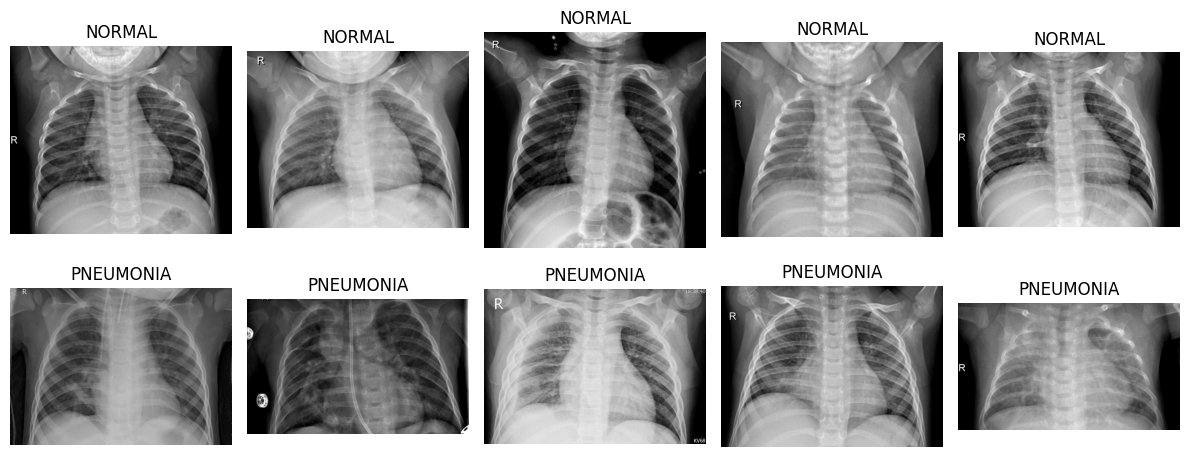

In [12]:
plt.figure(figsize=(12,5))

for c, name in [(0,"NORMAL"), (1,"PNEUMONIA")]:
    idx = np.where(labels == c)[0]
    chosen = np.random.default_rng(42).choice(
        idx, min(5, len(idx)), replace=False
    )

    for j, i in enumerate(chosen):
        img = Image.open(files[i]).convert("L")

        plt.subplot(2,5,c*5+j+1)
        plt.imshow(img, cmap="gray")
        plt.title(name)
        plt.axis("off")

plt.tight_layout()
plt.show()

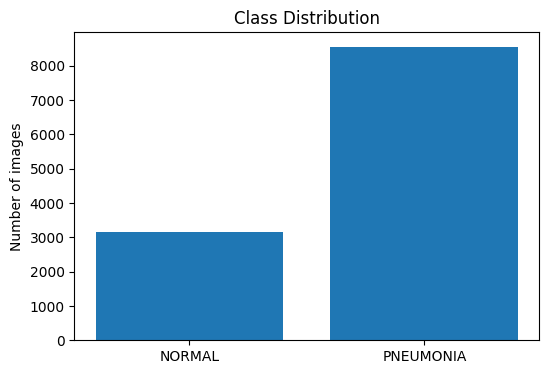

In [13]:
counts = [int((labels == 0).sum()), int((labels == 1).sum())]
plt.figure(figsize=(6,4))
plt.bar(["NORMAL", "PNEUMONIA"], counts)
plt.ylabel("Number of images")
plt.title("Class Distribution")
plt.show()

## Task 2 — Preprocessing and Feature Extraction

In [14]:
SIZE = (128, 128)

def extract_features(file):
    img = np.array(Image.open(file).convert("L").resize(SIZE))

    # HOG
    h = hog(img, pixels_per_cell=(16,16), cells_per_block=(2,2),
            feature_vector=True)

    # LBP
    lbp = local_binary_pattern(img, 8, 1, method="uniform")
    l = np.histogram(lbp, bins=np.arange(11), density=True)[0]

    # GLCM
    glcm = graycomatrix(img, [1], [0], levels=256,
                        symmetric=True, normed=True)
    g = np.array([graycoprops(glcm, p)[0,0] for p in
                  ["contrast","dissimilarity","homogeneity",
                   "energy","correlation"]])

    return np.r_[h, l, g], img

features, gray_images = [], []
for i, f in enumerate(files):
    feat, img = extract_features(f)
    features.append(feat)
    gray_images.append(img)

X_features = np.asarray(features, dtype=np.float32)
images = np.asarray(gray_images, dtype=np.float32)[..., None]

print("Feature-vector shape:", X_features.shape)
print("Image tensor shape:", images.shape)

Feature-vector shape: (11712, 1779)
Image tensor shape: (11712, 128, 128, 1)


In [15]:
# 70% train, 15% validation, 15% test
idx = np.arange(len(labels))

train_idx, temp_idx = train_test_split(
    idx, test_size=0.30, stratify=labels, random_state=SEED)

val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=labels[temp_idx], random_state=SEED)

print(f"Train: {len(train_idx)} ({len(train_idx)/len(idx):.0%})")
print(f"Validation: {len(val_idx)} ({len(val_idx)/len(idx):.0%})")
print(f"Test: {len(test_idx)} ({len(test_idx)/len(idx):.0%})")

Train: 8198 (70%)
Validation: 1757 (15%)
Test: 1757 (15%)


In [16]:
# CNN data
X_train = images[train_idx] / 255.0
X_val   = images[val_idx] / 255.0
X_test  = images[test_idx] / 255.0

y_train, y_val, y_test = labels[train_idx], labels[val_idx], labels[test_idx]

# Handcrafted feature data
F_train = X_features[train_idx]
F_val   = X_features[val_idx]
F_test  = X_features[test_idx]

## Task 3 — CNN Model and Hyperparameter Tuning

In [17]:
def make_cnn(filters=32, dropout=0.3, lr=1e-3):
    model = models.Sequential([
        layers.Input((128,128,1)),
        layers.Conv2D(filters, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(filters*2, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(filters*4, 3, activation="relu"),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(dropout),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="binary_crossentropy",
        metrics=["accuracy"])
    return model

# Small validation-based hyperparameter search
best_acc, best_model, best_config = -1, None, None

for filters in [16, 32]:
    for dropout in [0.3, 0.5]:
        m = make_cnn(filters, dropout)
        h = m.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=5, batch_size=32, verbose=0)
        acc = max(h.history["val_accuracy"])
        print(f"filters={filters}, dropout={dropout}, best_val_accuracy={acc:.4f}")
        if acc > best_acc:
            best_acc, best_model, best_config = acc, m, (filters, dropout)

print("Best configuration:", best_config)
print("Best validation accuracy:", round(best_acc, 4))

filters=16, dropout=0.3, best_val_accuracy=0.8685
filters=16, dropout=0.5, best_val_accuracy=0.8691
filters=32, dropout=0.3, best_val_accuracy=0.8788
filters=32, dropout=0.5, best_val_accuracy=0.8719
Best configuration: (32, 0.3)
Best validation accuracy: 0.8788


In [18]:
cnn_prob = best_model.predict(X_test, verbose=0).ravel()
cnn_pred = (cnn_prob >= 0.5).astype(int)

cnn_scores = [
    accuracy_score(y_test, cnn_pred),
    precision_score(y_test, cnn_pred, zero_division=0),
    recall_score(y_test, cnn_pred, zero_division=0),
    f1_score(y_test, cnn_pred, zero_division=0),
    roc_auc_score(y_test, cnn_prob)
]

cnn_results = pd.DataFrame([cnn_scores],
    columns=["Accuracy","Precision","Recall","F1-score","AUROC"],
    index=["CNN"])

cnn_results

,Accuracy,Precision,Recall,F1-score,AUROC
CNN,0.863404,0.922204,0.887676,0.90461,0.9326


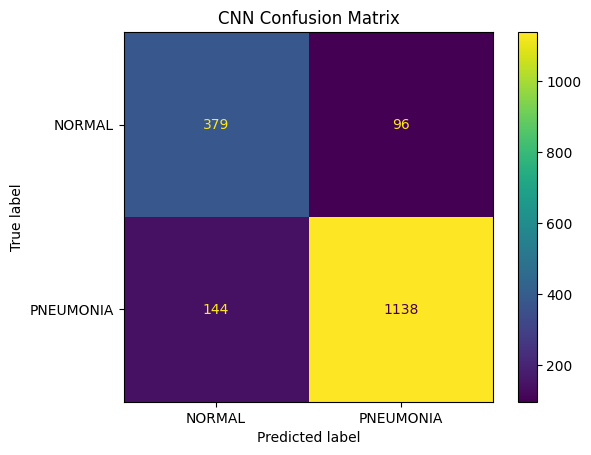

TN: 379  FP: 96  FN: 144  TP: 1138
False positives: 96 Normal images incorrectly classified as Pneumonia
False negatives: 144 Pneumonia images incorrectly classified as Normal


In [19]:
cm = confusion_matrix(y_test, cnn_pred)
tn, fp, fn, tp = cm.ravel()

ConfusionMatrixDisplay(
    cm, display_labels=["NORMAL", "PNEUMONIA"]
).plot()
plt.title("CNN Confusion Matrix")
plt.show()

print("TN:", tn, " FP:", fp, " FN:", fn, " TP:", tp)
print("False positives:", fp,
      "Normal images incorrectly classified as Pneumonia")
print("False negatives:", fn,
      "Pneumonia images incorrectly classified as Normal")

## Handcrafted Feature Model — HOG + LBP + GLCM

In [23]:
feature_model = models.Sequential([
    layers.Input(shape=(F_train.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

feature_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

feature_model.fit(
    F_train,
    y_train,
    validation_data=(F_val, y_val),
    epochs=5,
    batch_size=32,
    verbose=1
)

feature_prob = feature_model.predict(F_test, verbose=0).ravel()
feature_pred = (feature_prob >= 0.5).astype(int)

feature_scores = [
    accuracy_score(y_test, feature_pred),
    precision_score(y_test, feature_pred, zero_division=0),
    recall_score(y_test, feature_pred, zero_division=0),
    f1_score(y_test, feature_pred, zero_division=0),
    roc_auc_score(y_test, feature_prob)
]

print("Handcrafted Feature Model Results:")
print("Accuracy :", feature_scores[0])
print("Precision:", feature_scores[1])
print("Recall   :", feature_scores[2])
print("F1-score :", feature_scores[3])
print("AUROC    :", feature_scores[4])

Epoch 1/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8792 - loss: 0.3118 - val_accuracy: 0.9454 - val_loss: 0.1464
Epoch 2/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9408 - loss: 0.1590 - val_accuracy: 0.9425 - val_loss: 0.1416
Epoch 3/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9504 - loss: 0.1394 - val_accuracy: 0.9590 - val_loss: 0.1193
Epoch 4/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9545 - loss: 0.1258 - val_accuracy: 0.9607 - val_loss: 0.1122
Epoch 5/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9543 - loss: 0.1206 - val_accuracy: 0.9641 - val_loss: 0.1017
Handcrafted Feature Model Results:
Accuracy : 0.9493454752418896
Precision: 0.9798873692679002
Recall   : 0.9500780031201248
F1-score : 0.9647524752475247
AUROC    : 0.9921027999014697


<Figure size 700x500 with 0 Axes>

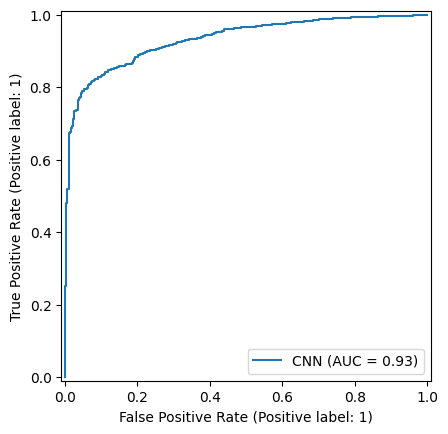

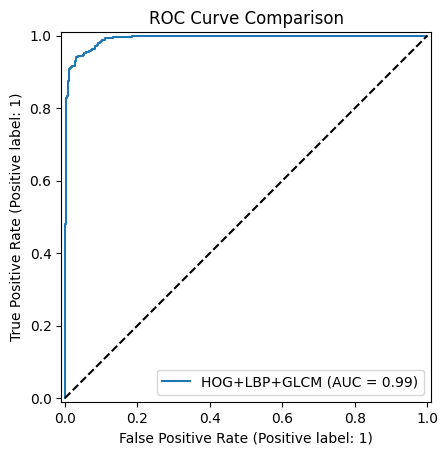

In [24]:
plt.figure(figsize=(7,5))
RocCurveDisplay.from_predictions(y_test, cnn_prob, name="CNN")
RocCurveDisplay.from_predictions(y_test, feature_prob, name="HOG+LBP+GLCM")
plt.plot([0,1], [0,1], "k--")
plt.title("ROC Curve Comparison")
plt.show()

## Conclusion

The chest X-ray images were resized to 128×128 and converted to grayscale. HOG, LBP and GLCM were extracted to create handcrafted feature vectors. The data was divided into training, validation and testing sets in a 70/15/15 ratio. A CNN was trained and tuned using validation performance. Accuracy, Precision, Recall, F1-score and AUROC were calculated, and a confusion matrix was used to inspect false positives and false negatives. The CNN and handcrafted-feature model were compared using the same evaluation metrics.


## Viva Points
- **HOG:** captures local edge and gradient orientation information.
- **LBP:** describes local texture patterns.
- **GLCM:** captures gray-level spatial relationships and texture statistics.
- **Precision:** proportion of predicted pneumonia cases that are actually pneumonia.
- **Recall:** proportion of actual pneumonia cases correctly detected.
- **F1-score:** harmonic mean of precision and recall.
- **AUROC:** measures discrimination across classification thresholds.
- **False positive:** Normal predicted as Pneumonia.
- **False negative:** Pneumonia predicted as Normal.